# MNIST Autoencoders: Dense, Convolutional, Reconstruction, and Denoising

This notebook develops autoencoders progressively on MNIST. It covers:

- dense autoencoders,
- convolutional autoencoders with transposed-convolution decoders,
- reconstruction error,
- alternative output activation and loss choices,
- the effect of reconstruction on a downstream classifier,
- and denoising of corrupted images.

A latent dimension of 32 is used throughout the main autoencoder experiments so the architectural differences can be compared more clearly.


## Imports and MNIST Data


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, confusion_matrix

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


## Build Class-Wise Test Index Lists


In [3]:
sample = [[] for i in range(10)]
for i,y in enumerate(y_test):
  sample[y].append(i)
# sample[i] is a list containing the indices of all instances of class i


## Visualize One Random Example from Each Digit Class


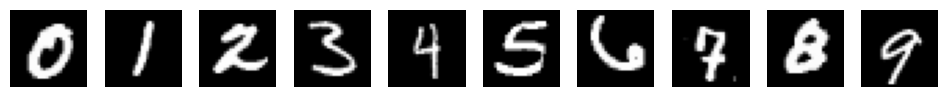

In [4]:
rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]

fig, ax = plt.subplots(1, 10, figsize=(12,1))
for i in range(10):
  ax[i].imshow(x_test[random_sel[i]], cmap = "gray")
  ax[i].axis("off")


# Dense Autoencoder

The dense autoencoder compresses each 28×28 image into a 32-dimensional latent vector and reconstructs the image through a symmetric fully connected decoder.


In [5]:
LATENT_SIZE = 32

encoder = tf.keras.models.Sequential()
encoder.add(Input(shape=(28,28)))
encoder.add(Flatten())
encoder.add(Dense(512, activation='relu'))
encoder.add(Dense(256, activation='relu'))
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))
encoder.add(Dense(LATENT_SIZE))

decoder = tf.keras.models.Sequential()
decoder.add(Input(shape=(LATENT_SIZE,)))
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))
decoder.add(Dense(256, activation='relu'))
decoder.add(Dense(512, activation='relu'))
decoder.add(Dense(784, activation='sigmoid'))
decoder.add(Reshape((28, 28)))

img = Input(shape = (28, 28))
latent_vector = encoder(img)
output = decoder(latent_vector)
model = Model(inputs = img, outputs = output)
model.compile(optimizer="adam",loss = "binary_crossentropy")
model.summary()


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32)             │       576,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       577,232 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153,712 (4.40 MB)

 Trainable params: 1,153,712 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Dense Autoencoder with Periodic Reconstruction Checks

Training is performed in blocks so reconstructed digit examples can be inspected during optimization.


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 0.2785
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1865
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1543
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1376
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1272
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1209
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1153
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1114
Epoch 9/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1083
Epoch 10/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1058


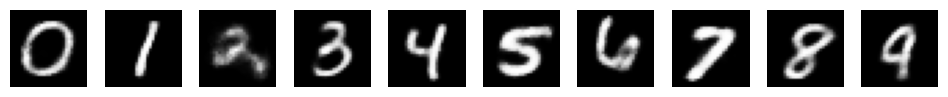

Epoch 11/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1038
Epoch 12/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1020
Epoch 13/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1003
Epoch 14/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0988
Epoch 15/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0974
Epoch 16/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0962
Epoch 17/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0952
Epoch 18/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0943
Epoch 19/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0936
Epoch 20/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0929


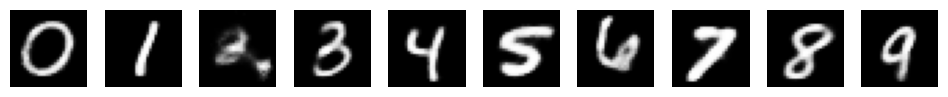

Epoch 21/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0922
Epoch 22/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0916
Epoch 23/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0911
Epoch 24/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0904
Epoch 25/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0899
Epoch 26/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0893
Epoch 27/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0887
Epoch 28/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0883
Epoch 29/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0878
Epoch 30/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0874


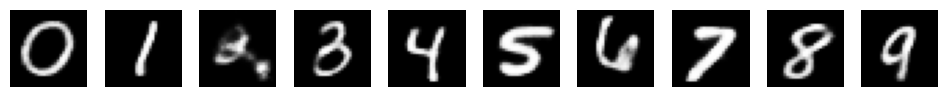

Epoch 31/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0868
Epoch 32/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0864
Epoch 33/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0861
Epoch 34/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0858
Epoch 35/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0854
Epoch 36/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0849
Epoch 37/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0848
Epoch 38/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0844
Epoch 39/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0841
Epoch 40/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0839


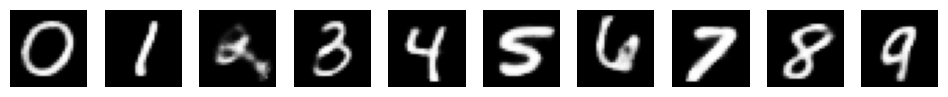

Epoch 41/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0836
Epoch 42/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0835
Epoch 43/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0832
Epoch 44/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0829
Epoch 45/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0827
Epoch 46/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0825
Epoch 47/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0825
Epoch 48/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0821
Epoch 49/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0819
Epoch 50/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0819


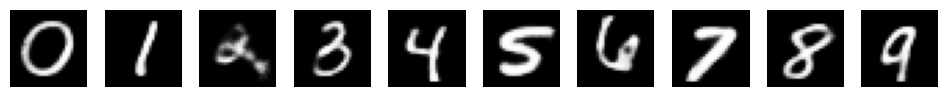

Epoch 51/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0816
Epoch 52/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0814
Epoch 53/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0814
Epoch 54/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0812
Epoch 55/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0810
Epoch 56/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0809
Epoch 57/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0807
Epoch 58/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0806
Epoch 59/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0805
Epoch 60/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0804


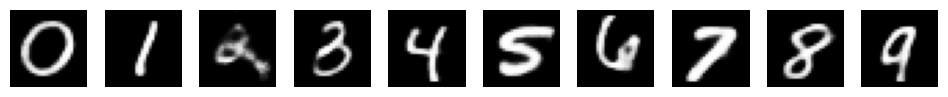

Epoch 61/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0802
Epoch 62/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0801
Epoch 63/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0800
Epoch 64/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0798
Epoch 65/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0798
Epoch 66/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0797
Epoch 67/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0795
Epoch 68/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0794
Epoch 69/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0793
Epoch 70/70
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0792


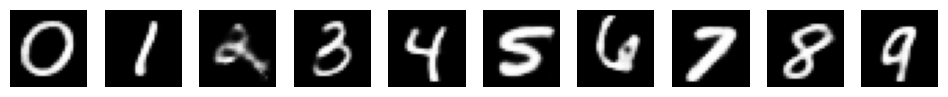

Epoch 71/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0792
Epoch 72/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0791
Epoch 73/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0789
Epoch 74/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0789
Epoch 75/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0788
Epoch 76/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0786
Epoch 77/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0785
Epoch 78/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0785
Epoch 79/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0784
Epoch 80/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0783


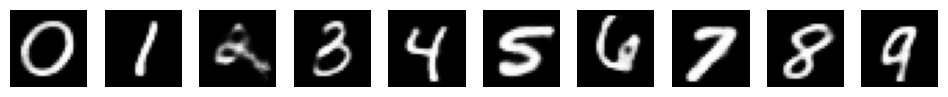

Epoch 81/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0783
Epoch 82/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0782
Epoch 83/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0781
Epoch 84/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0780
Epoch 85/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0779
Epoch 86/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0779
Epoch 87/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0779
Epoch 88/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0778
Epoch 89/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0778
Epoch 90/90
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0776


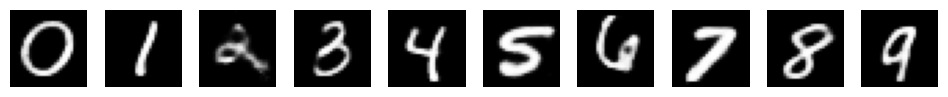

Epoch 91/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0776
Epoch 92/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0775
Epoch 93/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0775
Epoch 94/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0773
Epoch 95/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0774
Epoch 96/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0773
Epoch 97/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0773
Epoch 98/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0772
Epoch 99/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0771
Epoch 100/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0771


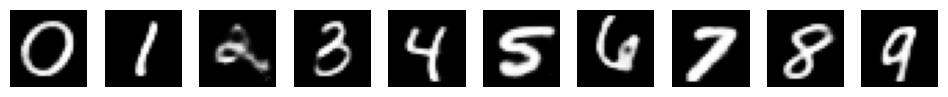

In [6]:
EPOCHS = 100
display_freq = 10
rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
for epoch in range(0,EPOCHS,display_freq):
    history = model.fit(x_train, x_train, batch_size = 500,verbose=1,initial_epoch=epoch,epochs=epoch+display_freq)
    rec = model.predict(x_test[random_sel],verbose=0)
    fig, ax = plt.subplots(1, 10, figsize=(12,1))
    for i in range(10):
      ax[i].imshow(rec[i], cmap = "gray")
      ax[i].axis("off")
    plt.show()
    mse = np.mean((rec-x_test[random_sel])**2)


## Dense Autoencoder Reconstruction Error


In [7]:
code_trn = encoder.predict(x_train,verbose=0)
images_trn = decoder.predict(code_trn,verbose=0)
print(f'Training set MSE = {np.mean((x_train-images_trn)**2):.8f}')

code_tst = encoder.predict(x_test,verbose=0)
images_tst = decoder.predict(code_tst,verbose=0)
print(f'Test set MSE = {np.mean((x_test-images_tst)**2):.8f}')


Training set MSE = 0.00529815
Test set MSE = 0.00622448


## Dense Autoencoder Reconstructions


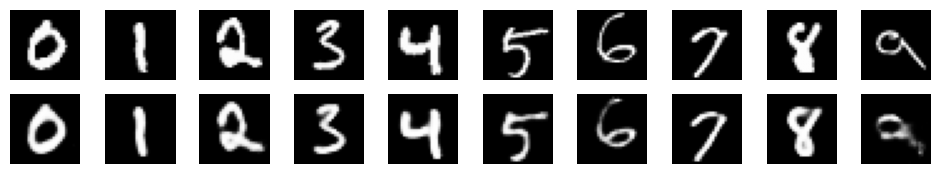

In [8]:
rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
fig, ax = plt.subplots(2, 10, figsize=(12,2))
for i in range(10):
    ax[0,i].imshow(x_test[random_sel[i]], cmap = "gray")
    ax[0,i].axis("off")
    ax[1,i].imshow(images_tst[random_sel[i]], cmap = "gray")
    ax[1,i].axis("off")
plt.show()


# Convolutional Autoencoder

The convolutional encoder uses convolution and max pooling to compress spatial features. The decoder expands the latent representation with dense reshaping and transposed convolutions.


In [9]:
LATENT_SIZE = 32

conv_encoder = tf.keras.models.Sequential()
conv_encoder.add(Input(shape=(28,28,1)))
conv_encoder.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
conv_encoder.add(MaxPooling2D((2, 2), padding="same"))
conv_encoder.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
conv_encoder.add(MaxPooling2D((2, 2), padding="same"))
conv_encoder.add(Flatten())
conv_encoder.add(Dense(LATENT_SIZE,))

conv_decoder = tf.keras.models.Sequential()
conv_decoder.add(Input(shape=(LATENT_SIZE,)))
conv_decoder.add(Dense(7*7*32,activation="relu"))
conv_decoder.add(Reshape((7, 7,32)))
conv_decoder.add(Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"))
conv_decoder.add(Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"))
conv_decoder.add(Conv2D(1, (3, 3), activation="sigmoid", padding="same"))

img = Input(shape = (28, 28, 1))
latent_vector = conv_encoder(img)
output = conv_decoder(latent_vector)
conv_autoencoder = Model(inputs = img, outputs = output)
conv_autoencoder.compile(optimizer="adam",loss = "binary_crossentropy")
conv_autoencoder.summary()


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 32)             │        59,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │        70,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,305 (509.00 KB)

 Trainable params: 130,305 (509.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Convolutional Autoencoder


In [10]:
history = conv_autoencoder.fit(x_train, x_train, batch_size = 512,verbose=1, epochs=50)


Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - loss: 0.3122
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1862
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1163
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1003
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0936
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0895
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0867
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0846
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0832
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0820
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0811
Epoch 12/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0803
Epoch 13/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0796
Epoch 14/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0791
Epoch 15/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - 

## Convolutional Autoencoder Reconstruction Error


In [11]:
code_trn = conv_encoder.predict(x_train,verbose=0)
images_trn = conv_decoder.predict(code_trn,verbose=0).squeeze()
print(f'Training set MSE = {np.mean((x_train-images_trn)**2):.8f}')

code_tst = conv_encoder.predict(x_test,verbose=0)
images_tst = conv_decoder.predict(code_tst,verbose=0).squeeze()
print(f'Test set MSE = {np.mean((x_test - images_tst)**2):.8f}')


Training set MSE = 0.00389937
Test set MSE = 0.00398154


# Alternative Output Activation and Reconstruction Loss

The next convolutional autoencoder replaces the sigmoid output with a linear convolution followed by a clipped ReLU and trains with mean squared error. This preserves the original experiment while keeping the evaluation tied to the correct convolutional encoder and decoder.


In [12]:
LATENT_SIZE = 32

conv_encoder = tf.keras.models.Sequential()
conv_encoder.add(Input(shape=(28,28,1)))
conv_encoder.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
conv_encoder.add(MaxPooling2D((2, 2), padding="same"))
conv_encoder.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
conv_encoder.add(MaxPooling2D((2, 2), padding="same"))
conv_encoder.add(Flatten())
conv_encoder.add(Dense(LATENT_SIZE,))

conv_decoder = tf.keras.models.Sequential()
conv_decoder.add(Input(shape=(LATENT_SIZE,)))
conv_decoder.add(Dense(7*7*32,activation="relu"))
conv_decoder.add(Reshape((7, 7, 32)))
#conv_decoder.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
conv_decoder.add(Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"))
#conv_decoder.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
conv_decoder.add(Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"))
conv_decoder.add(Conv2D(1, (3, 3), padding="same"))
conv_decoder.add(ReLU(max_value=1))

img = Input(shape = (28, 28, 1))
latent_vector = conv_encoder(img)
output = conv_decoder(latent_vector)
conv_autoencoder = Model(inputs = img, outputs = output)
conv_autoencoder.compile(optimizer="adam",loss = "mse")
conv_autoencoder.summary()


Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 32)             │        59,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 28, 28, 1)      │        70,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,305 (509.00 KB)

 Trainable params: 130,305 (509.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate the MSE-Based Convolutional Autoencoder


Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0520
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0150
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0098
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0080
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0071
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0066
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0062
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0059
Epoch 9/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0056
Epoch 10/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054
Epoch 11/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0053
Epoch 12/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0052
Epoch 13/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0051
Epoch 14/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0049
Epoch 15/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

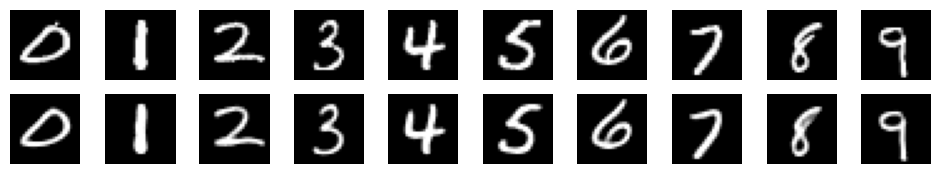

In [13]:
history_mse = conv_autoencoder.fit(
    x_train,
    x_train,
    batch_size=500,
    verbose=1,
    epochs=50,
)

code_trn_mse = conv_encoder.predict(x_train, verbose=0)
images_trn_mse = conv_decoder.predict(code_trn_mse, verbose=0).squeeze()

code_tst_mse = conv_encoder.predict(x_test, verbose=0)
images_tst_mse = conv_decoder.predict(code_tst_mse, verbose=0).squeeze()

print(
    f"Training set MSE = "
    f"{np.mean((x_train - images_trn_mse) ** 2):.8f}"
)
print(
    f"Test set MSE = "
    f"{np.mean((x_test - images_tst_mse) ** 2):.8f}"
)

rs = [
    np.random.randint(0, len(sample[i]))
    for i in range(10)
]
random_sel = [
    sample[i][r]
    for i, r in enumerate(rs)
]

fig, ax = plt.subplots(
    2,
    10,
    figsize=(12, 2),
)

for i in range(10):
    ax[0, i].imshow(
        x_test[random_sel[i]],
        cmap="gray",
    )
    ax[0, i].axis("off")

    ax[1, i].imshow(
        images_tst_mse[random_sel[i]],
        cmap="gray",
    )
    ax[1, i].axis("off")

plt.show()


# Effect of Reconstruction on Downstream Classification

A CNN classifier is trained on the original MNIST images. Its test accuracy is then measured on both the original test set and the reconstructed test images from the convolutional autoencoder.


In [14]:
def cnn_model(input_shape=(28,28,1), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
model.compile(optimizer="adam", loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=512,
    verbose = 1,
    validation_data=(x_test, y_test),
  )


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.8708 - loss: 0.4561 - val_accuracy: 0.9616 - val_loss: 0.1226
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9716 - loss: 0.0962 - val_accuracy: 0.9808 - val_loss: 0.0614
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9814 - loss: 0.0626 - val_accuracy: 0.9844 - val_loss: 0.0462
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9850 - loss: 0.0498 - val_accuracy: 0.9857 - val_loss: 0.0432
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9873 - loss: 0.0414 - val_accuracy: 0.9869 - val_loss: 0.0356
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0348 - val_accuracy: 0.9887 - val_loss: 0.0352
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9905 - loss: 0.0305 - val_accuracy: 0.9887 - val_loss: 0.0338
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9921 - loss: 0.0259 - val_accuracy: 

## Classifier Accuracy on Original Test Images


In [15]:
pred = model.predict(x_test,verbose=0)
accuracy = accuracy_score(y_test, np.argmax(pred,axis=1))
print(f'Test set accuracy {accuracy:.4}')


Test set accuracy 0.9905


## Classifier Accuracy on Reconstructed Test Images


In [16]:
pred_reconstructed = model.predict(
    images_tst_mse,
    verbose=0,
)

reconstructed_accuracy = accuracy_score(
    y_test,
    np.argmax(
        pred_reconstructed,
        axis=1,
    ),
)

print(
    f"Reconstructed test set accuracy "
    f"{reconstructed_accuracy:.4f}"
)


Reconstructed test set accuracy 0.9875


# Denoising with the Convolutional Autoencoder

Noise is added to the MNIST test images and clipped to the valid [0, 1] range. The trained convolutional autoencoder is then used as a denoiser.


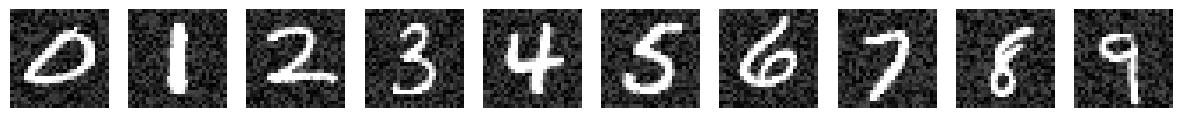

In [17]:
noisy_x_test = np.clip(x_test + np.random.random(size = x_test.shape)*.3,0,1)
random_sel = [sample[i][r] for i,r in enumerate(rs)]

fig, ax = plt.subplots(1, 10, figsize=(15,2))
for i in range(10):
  ax[i].imshow(noisy_x_test[random_sel[i]], cmap = "gray")
  ax[i].axis("off")


## Denoise the Corrupted Test Images


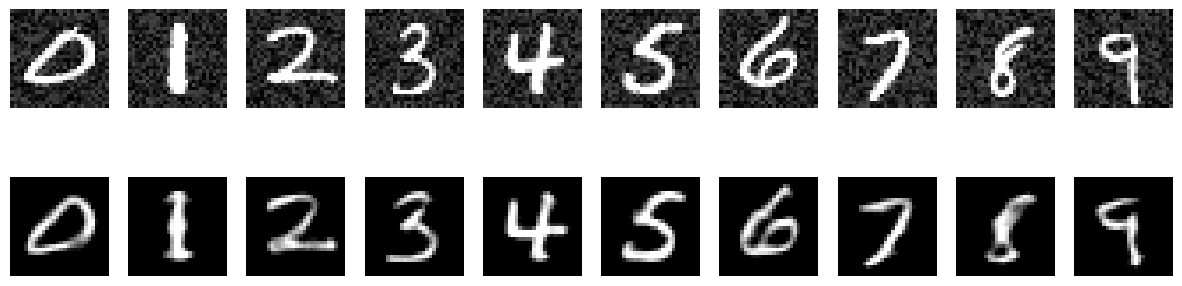

In [18]:
denoised_x_test = conv_autoencoder.predict(
    noisy_x_test,
    verbose=0,
).squeeze()

fig, ax = plt.subplots(
    2,
    10,
    figsize=(15, 4),
)

for i in range(10):
    ax[0, i].imshow(
        noisy_x_test[random_sel[i]],
        cmap="gray",
    )
    ax[0, i].axis("off")

    ax[1, i].imshow(
        denoised_x_test[random_sel[i]],
        cmap="gray",
    )
    ax[1, i].axis("off")

plt.show()


## Classifier Accuracy: Noisy vs Denoised Images

The final comparison evaluates whether the convolutional autoencoder improves downstream classification after image corruption.


In [19]:
pred_noisy = model.predict(
    noisy_x_test,
    verbose=0,
)

noisy_accuracy = accuracy_score(
    y_test,
    np.argmax(
        pred_noisy,
        axis=1,
    ),
)

pred_denoised = model.predict(
    denoised_x_test,
    verbose=0,
)

denoised_accuracy = accuracy_score(
    y_test,
    np.argmax(
        pred_denoised,
        axis=1,
    ),
)

print(
    f"Noisy test set accuracy: "
    f"{noisy_accuracy:.4f}"
)
print(
    f"Denoised test set accuracy: "
    f"{denoised_accuracy:.4f}"
)


Noisy test set accuracy: 0.9850
Denoised test set accuracy: 0.9707


## Key Takeaways

Dense and convolutional autoencoders both learn compressed representations without class labels. The convolutional architecture preserves spatial structure more naturally and supports image reconstruction and denoising through learned decoder operations.

The downstream classifier experiments show how reconstruction quality can be evaluated not only with pixel-level error but also by measuring whether task-relevant information is preserved.
